# Evaluate Generation on Unseen Protocols.

## Prepare Notebook.

### Import Libraries.

In [25]:
import os
import sys
import yaml

import cloudpickle
import scanpy as sc
import numpy as np


### Constants and Paths.

In [26]:
h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO012/projected_LPHO12_all_exp.h5ad"
simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_00-13-52_fe274fa7"
config_path = os.path.join(simulation_data_dir, "config.yaml")
results_path = os.path.join(simulation_data_dir, "fwd_results.npz")
cond_data_path = os.path.join(simulation_data_dir, "condition_data.pkl")


### Read Data.

### Read real measurements.

In [10]:
adata_real = sc.read_h5ad(h5ad_path)
adata_real

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'Unnamed: 25', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'cell_type', 'annotation_final'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'meta', 'processing_steps'
    obsm: 'X_pca', 'X_umap', 'rep'
    layers: 'positives', 'raw'

In [23]:
adata_real.obs["experiment_number"]

269894-6     208
89129-16     206
190653-25    210
153604-16    206
155750-1     207
            ... 
205367-19    206
43311-1      207
183718-3     206
46387-26     205
40957-14     207
Name: experiment_number, Length: 100000, dtype: category
Categories (6, object): ['205', '206', '207', '208', '209', '210']

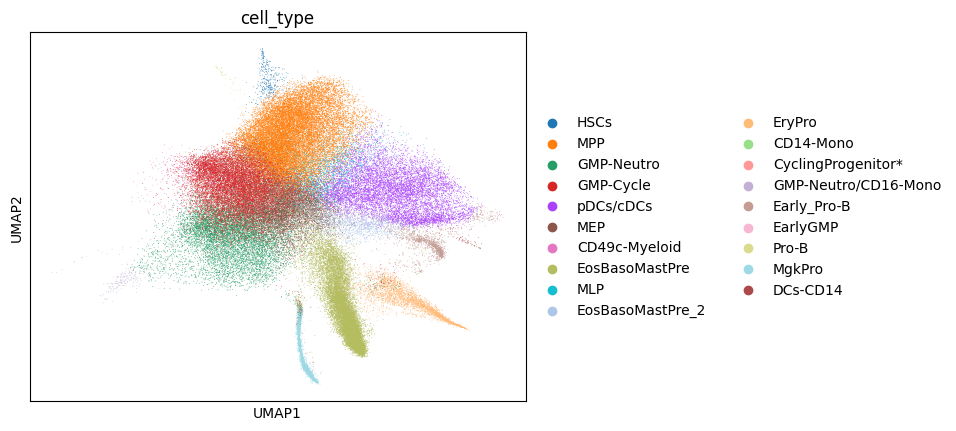

In [18]:
sc.pl.embedding(adata_real, "umap", color="cell_type")

### Read configurations and results.

In [27]:
with open(config_path, "r") as fb:
    config_dict = yaml.safe_load(fb)
config_dict.keys()


dict_keys(['annotation', 'callbacks', 'data', 'flow_matching', 'model', 'paths', 'split', 'training', 'transforms', 'vf', 'reproducibility', 'sampling'])

### Read simulated data.

In [28]:
sim_data = np.load(results_path)
sim_data.keys()

KeysView(NpzFile '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_00-13-52_fe274fa7/fwd_results.npz' with keys: X, X_channel, X_scatter, ct_logits, ct_probs)

In [29]:
with open(cond_data_path, "rb") as fb:
    protocol_data = cloudpickle.load(fb)